In [17]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV, cross_validate
import shap
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer

df_responses = pd.read_excel("../data/responses.xlsx")
df_features = pd.read_excel("../data/sm_numeric_features.xlsx")

### Data-Responses 

In [18]:
print(df_responses.head(5))


   prompt_id  ...                                           response
0          1  ...  A solar eclipse occurs when the Moon passes di...
1          1  ...  A solar eclipse occurs when the Moon passes di...
2          1  ...  A solar eclipse is a breathtaking celestial ev...
3          1  ...  A solar eclipse occurs when the Moon passes be...
4          1  ...  A solar eclipse occurs when the moon passes di...

[5 rows x 5 columns]


### Data-Features after Extraction

In [19]:
print(df_features.head(5))

   prompt_id     category   model  ...  PS_AGREEMENT  SY_NARRATIVE  SY_QUESTION
0          1  explanation     gpt  ...      0.018750           1.0          0.0
1          1  explanation  claude  ...      0.010989           1.0          0.0
2          1  explanation  gemini  ...      0.000000           1.0          0.0
3          1  explanation    qwen  ...      0.012658           1.0          0.0
4          1  explanation   llama  ...      0.005780           1.0          0.0

[5 rows x 21 columns]


### Model Training

In [20]:
df=df_features
#variables
X = df[[
    "avg_sentence_length",
    "punctuation_frequency",
    "noun_ratio", "verb_ratio", "adj_ratio", "adv_ratio",
    "ST_TYPE_TOKEN_RATIO_LEMMAS",
    "G_PASSIVE", "G_ACTIVE",
    "G_PRESENT", "G_PAST",
    "L_I_PRON",
    "PS_CONTRADICTION", "PS_AGREEMENT"
]]
y = df["model"]


In [21]:

#RF model setup & cv
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#gridsearch parameters
param_grid = {
    "n_estimators": [5,10,20,30,50],
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [3, 5, 10]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X, y)


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [3, 5, ...], 'min_samples_leaf': [3, 5, ...], 'n_estimators': [5, 10, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [22]:

results = pd.DataFrame(grid_search.cv_results_)
results = results[["params", "mean_test_score", "std_test_score"]].copy()

#train test accuracy for gridsearch params combinations
train_scores = []
for params in results["params"]:
    model = RandomForestClassifier(random_state=42, **params)
    cv_result = cross_validate(model, X, y, cv=cv, 
                               scoring="accuracy",
                               return_train_score=True)
    train_scores.append(cv_result["train_score"].mean())

#choosing best params for both overfit and acc
results["train_accuracy"] = train_scores
results["overfit_gap"] = results["train_accuracy"] - results["mean_test_score"]
results["balanced_score"] = results["mean_test_score"] - 0.5 * results["overfit_gap"]
results = results.sort_values("balanced_score", ascending=False)
print(results.head(10).to_string(index=False))


# Final model w selected parameters
best_model = RandomForestClassifier(
    max_depth=3,
    min_samples_leaf=5,
    n_estimators=50,
    random_state=42
)

scores = cross_val_score(best_model, X, y, cv=cv, scoring="accuracy")
y_pred = cross_val_predict(best_model, X, y, cv=cv)

print(f"Accuracy: {scores.mean():.2f} (+/- {scores.std():.2f})")
print(classification_report(y, y_pred))

cv_result_final = cross_validate(best_model, X, y, cv=cv,
                                  scoring="accuracy",
                                  return_train_score=True)
print(f"Train accuracy (CV): {cv_result_final['train_score'].mean():.2f}")
print(f"Test accuracy (CV):  {scores.mean():.2f}")


#Shap values for attributes
best_model.fit(X, y)
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

                                                       params  mean_test_score  std_test_score  train_accuracy  overfit_gap  balanced_score
  {'max_depth': 3, 'min_samples_leaf': 3, 'n_estimators': 50}         0.538333        0.030092        0.660417     0.122083        0.477292
 {'max_depth': 7, 'min_samples_leaf': 10, 'n_estimators': 50}         0.566667        0.009129        0.749583     0.182917        0.475208
 {'max_depth': 3, 'min_samples_leaf': 10, 'n_estimators': 30}         0.535000        0.040620        0.661667     0.126667        0.471667
  {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 50}         0.536667        0.032745        0.667917     0.131250        0.471042
  {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 30}         0.533333        0.041833        0.662500     0.129167        0.468750
{'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 50}         0.561667        0.011304        0.757917     0.196250        0.463542
 {'max_depth': 7, 'm

### Visualizations

In [23]:
class_names = ["claude", "gemini", "gpt", "llama", "qwen"]

#conf matrix and feature importance
y_true = y
importances = pd.Series(best_model.feature_importances_, index=X.columns)


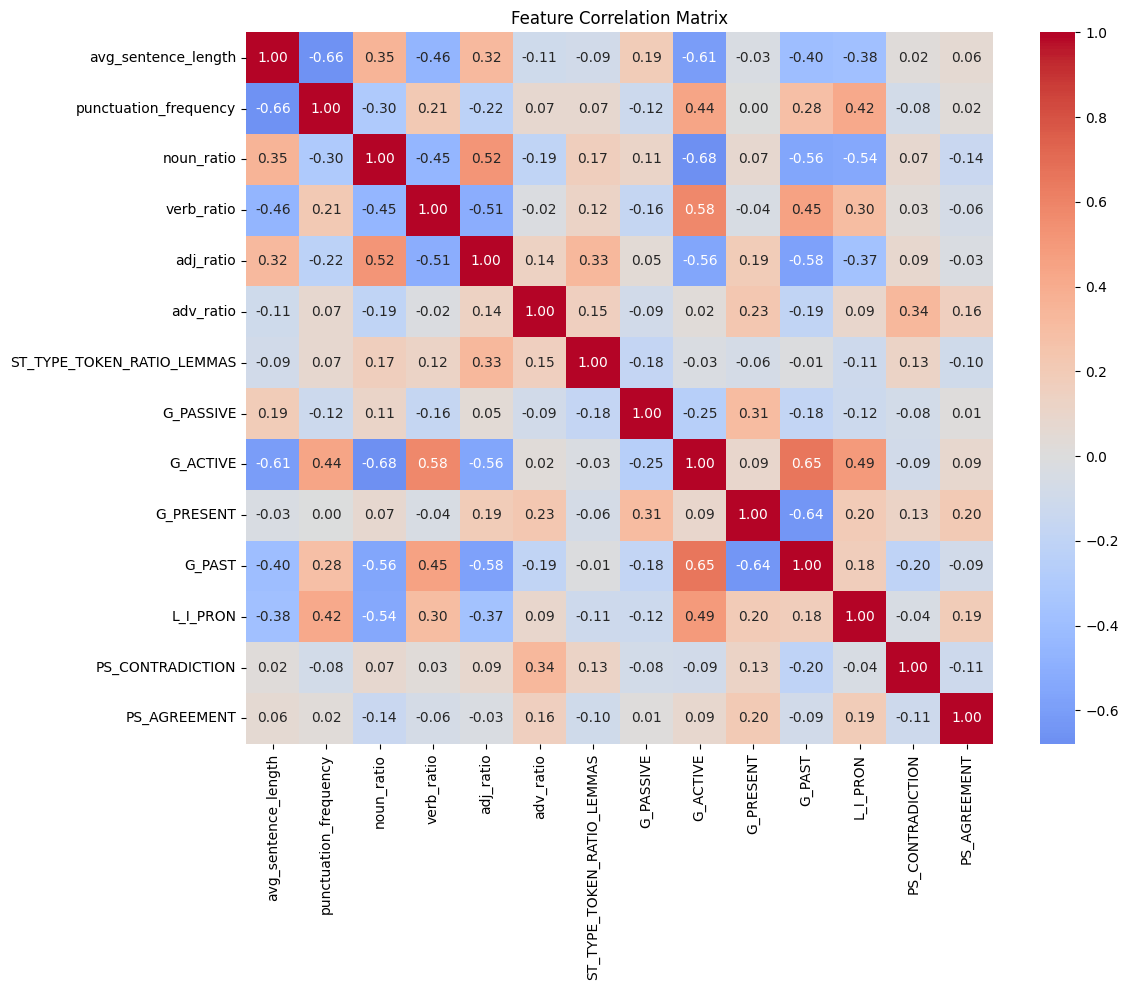

In [24]:

corr_matrix = X.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()



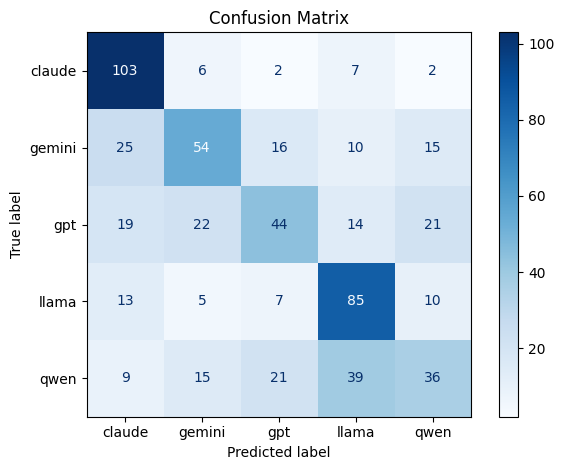

In [25]:

#conf matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


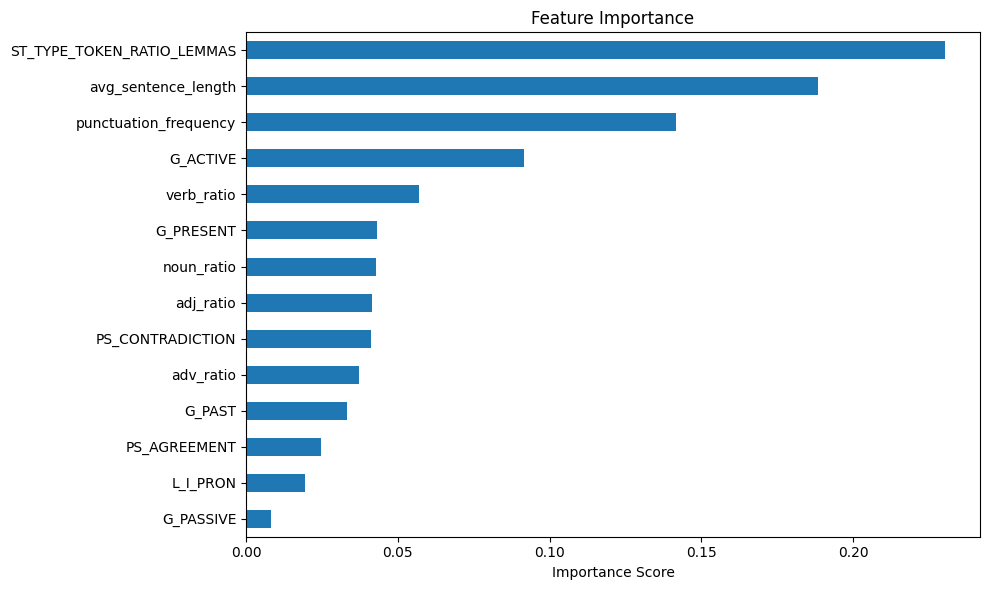

In [26]:

#feature importance
importances_sorted = importances.sort_values(ascending=True)
plt.figure(figsize=(10, 6))
importances_sorted.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


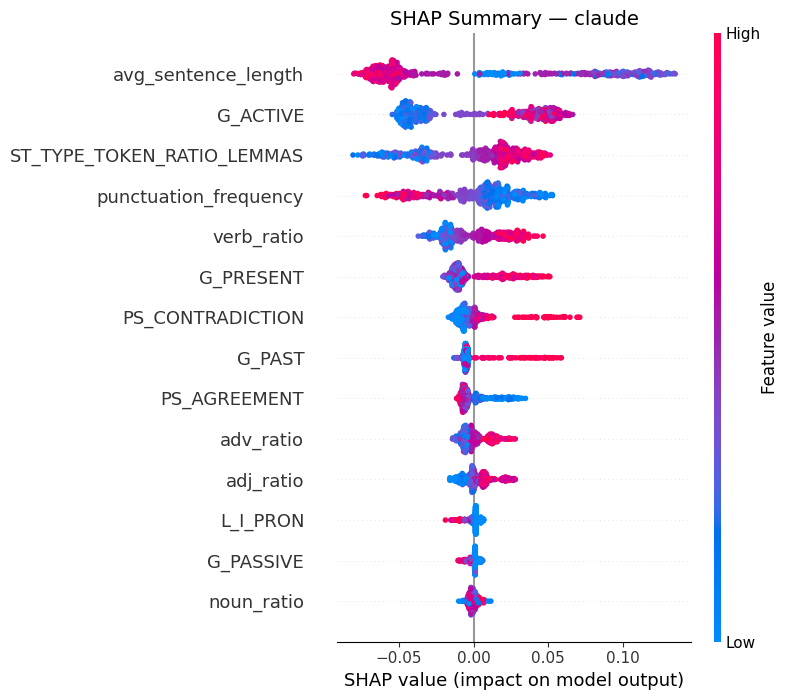

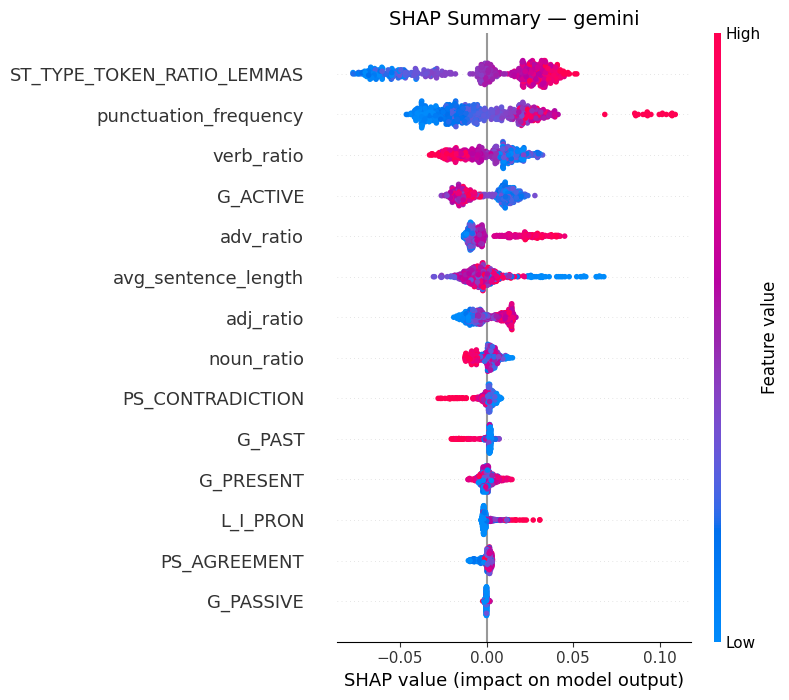

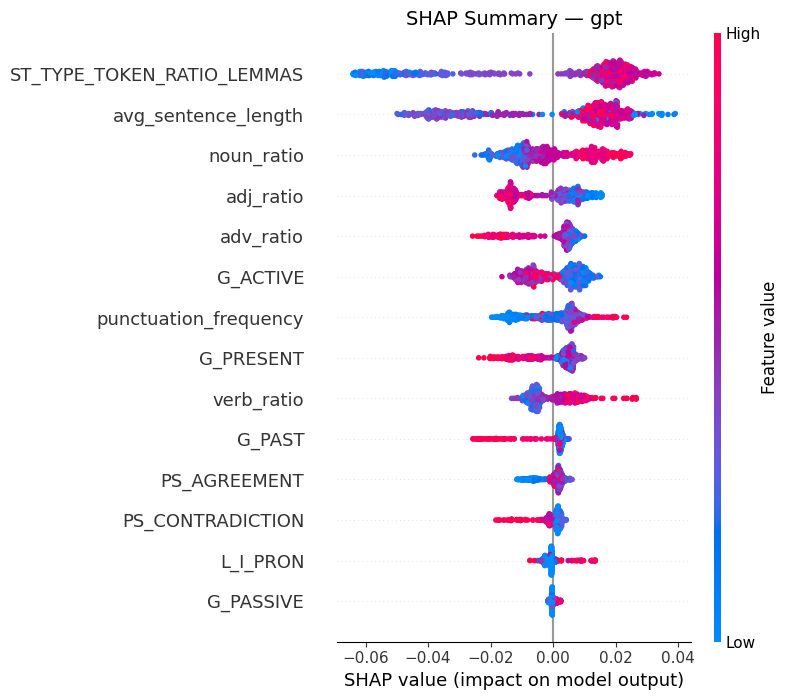

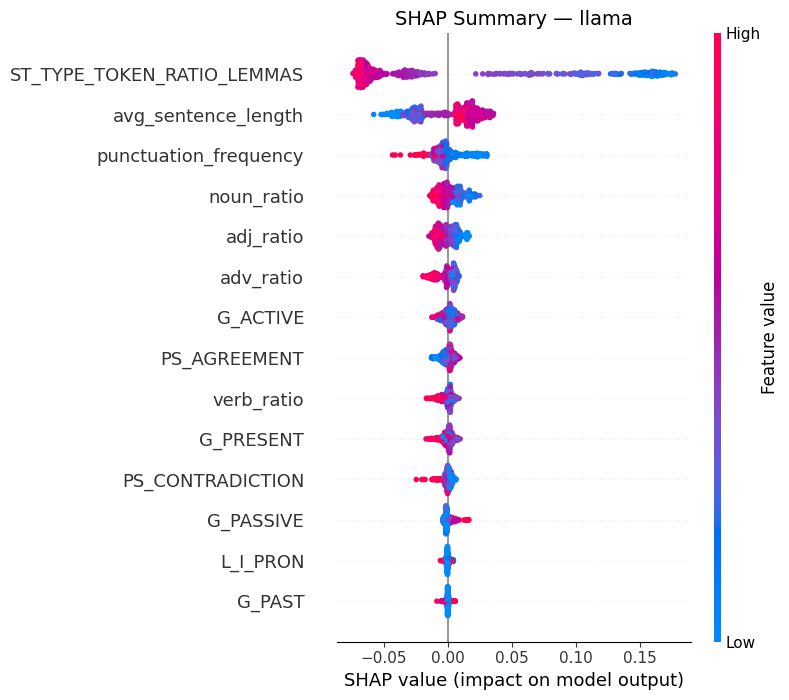

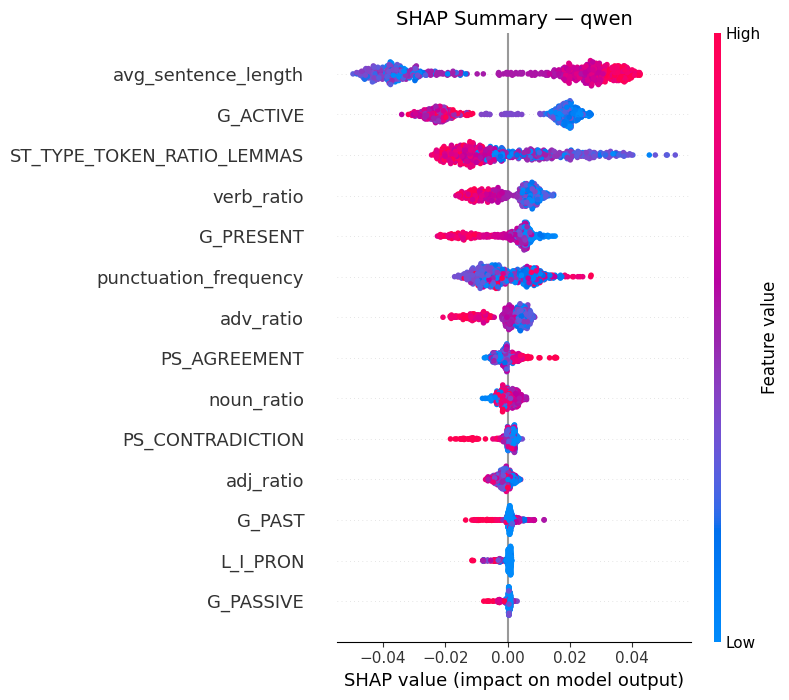

In [27]:


#SHAP values visualization
for i, model_name in enumerate(class_names):
    shap_vals_model = shap_values[:, :, i]

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_vals_model, X, plot_type="dot", show=False)
    plt.title(f"SHAP Summary — {model_name}", fontsize=14)
    plt.tight_layout()
    plt.show()



In [28]:

category = df["category"].values

print("Accuracy by genre:\n")
for cat in pd.Series(category).unique():
    mask = pd.Series(category) == cat
    y_true_cat = pd.Series(y_true)[mask]
    y_pred_cat = pd.Series(y_pred)[mask]
    acc = (y_true_cat == y_pred_cat).mean()
    print(f"{cat}: {acc:.2f}")



Accuracy by genre:

explanation: 0.44
opinion: 0.54
comparison: 0.59
narration: 0.52
argumentation: 0.57
dialogue: 0.56


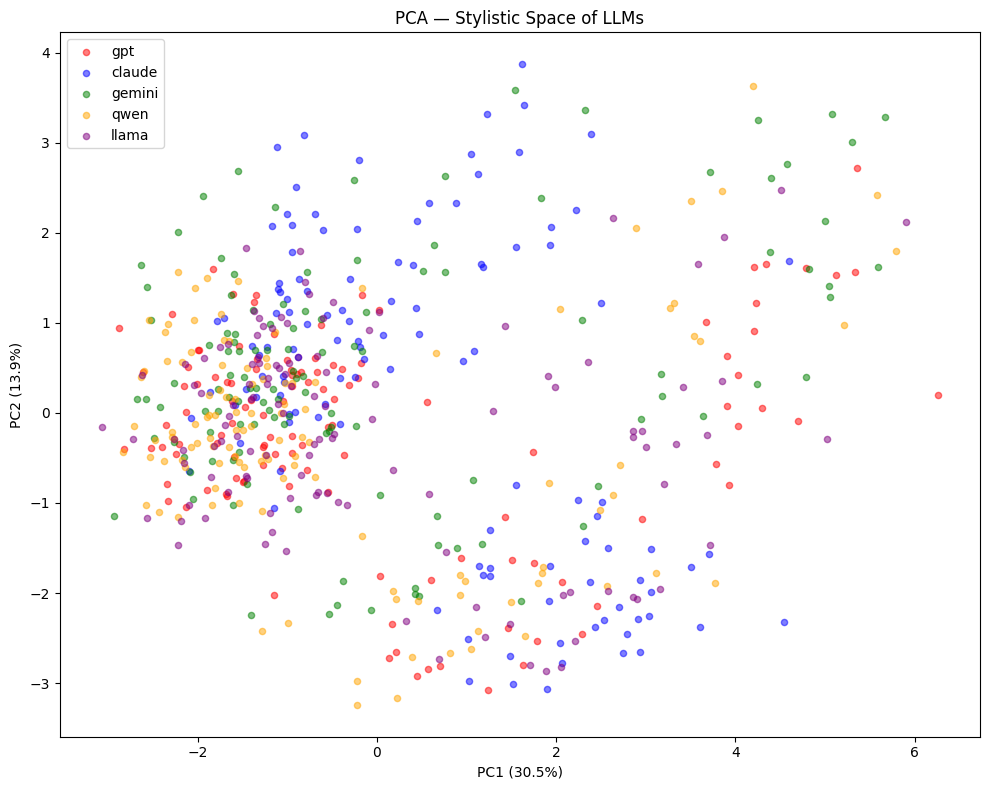

In [29]:
#PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))

colors = {"claude": "blue", "gemini": "green", "gpt": "red", "llama": "purple", "qwen": "orange"}

for model_name in df["model"].unique():
    mask = df["model"] == model_name
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=model_name,
                color=colors[model_name],
                alpha=0.5, s=20)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA — Stylistic Space of LLMs")
plt.legend()
plt.tight_layout()
plt.show()


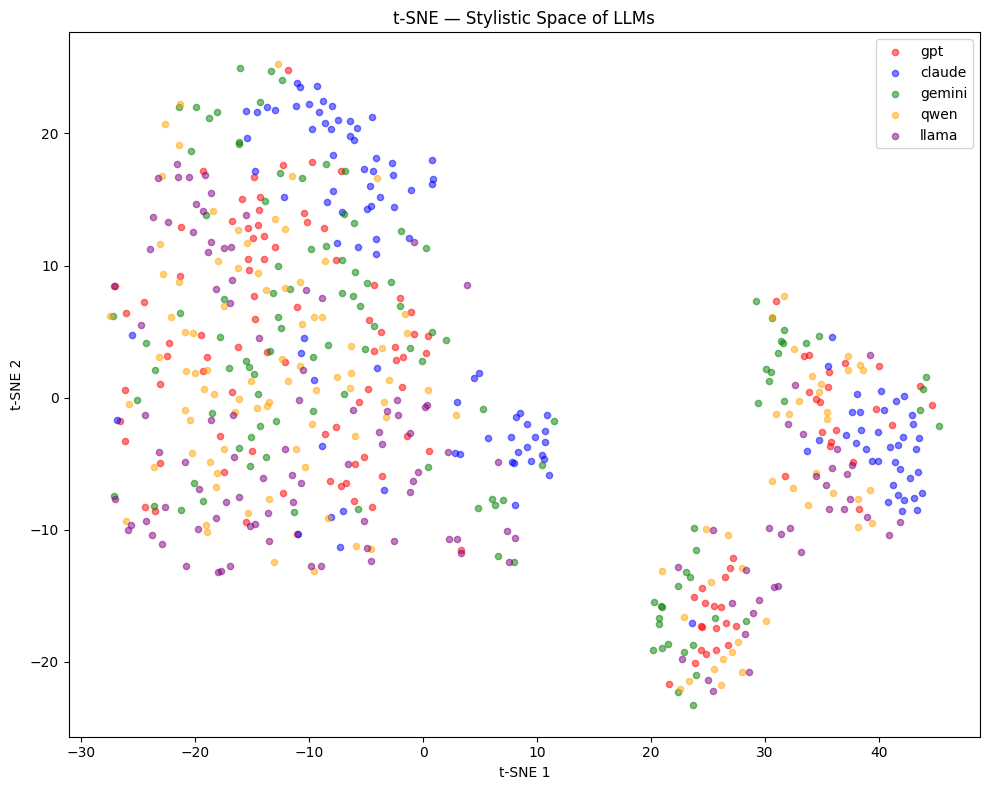

In [30]:

#t-sne
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 8))
for model_name in df["model"].unique():
    mask = df["model"] == model_name
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=model_name,
                color=colors[model_name],
                alpha=0.5, s=20)

plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE — Stylistic Space of LLMs")
plt.legend()
plt.tight_layout()
plt.show()


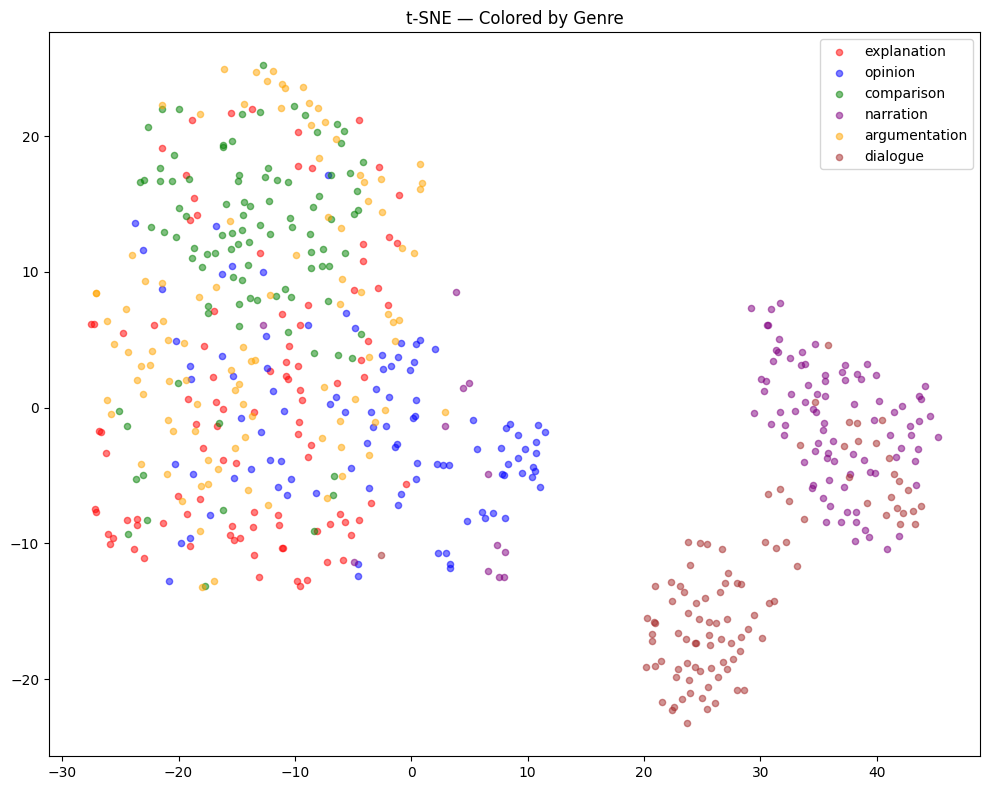

In [31]:

#tsne genre based
genre_colors = {
    "explanation": "red", "opinion": "blue",
    "comparison": "green", "narration": "purple",
    "argumentation": "orange", "dialogue": "brown"
}

plt.figure(figsize=(10, 8))
for cat in df["category"].unique():
    mask = df["category"] == cat
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=cat,
                color=genre_colors[cat],
                alpha=0.5, s=20)

plt.title("t-SNE — Colored by Genre")
plt.legend()
plt.tight_layout()
plt.show()

### N-gram analysis

In [32]:
results = {}

all_models = df_responses["model"].unique()
all_ngrams = {}

for model_name in all_models:
    texts = df_responses[df_responses["model"] == model_name]["response"].tolist()
    vectorizer = CountVectorizer(
        ngram_range=(2, 2),
        max_features=50,
        stop_words="english"
    )
    X_ngram = vectorizer.fit_transform(texts).toarray()
    freq = X_ngram.sum(axis=0)
    ngram_freq = pd.Series(freq, index=vectorizer.get_feature_names_out())
    all_ngrams[model_name] = ngram_freq

#all models
ngram_df = pd.DataFrame(all_ngrams).fillna(0)
print(ngram_df.shape)
print(ngram_df.head())

(173, 5)
                          gpt  claude  gemini  qwen  llama
advantages disadvantages  0.0     0.0     0.0   0.0    4.0
approach lead             0.0     0.0     0.0   0.0    4.0
barely whisper            6.0     0.0     3.0   0.0    0.0
began voice               0.0     0.0     0.0   4.0    0.0
black hole                0.0     4.0     0.0   0.0    7.0
